# Validation: fwap cylindrical-Biot dispersion against published figures

Plan I from
[`docs/plans/cylindrical_biot.md`](../plans/cylindrical_biot.md).

This notebook reproduces the dispersion curves from five published
borehole-acoustic figures and overlays them on the digitised
reference. Each section follows the same shape:

1. fwap dispersion curve(s) for the published geometry.
2. (TODO) overlay against the digitised reference CSV in
   [`_data/`](_data/README.md).
3. (TODO) per-curve RMS deviation gate (5 % budget).

**Status of overlays.** Steps 2 and 3 require digitised CSVs that
are not yet shipped. Each section flags its overlay status with the
`OVERLAY_AVAILABLE` global below; sections that cannot find their
CSV emit only the fwap curve and a clearly-marked TODO note. As
CSVs land in `_data/`, the overlay cells light up automatically.

References, in order of effort to digitise (cheapest first):

1. Paillet & Cheng 1991 fig 4.5 — Stoneley + pseudo-Rayleigh on
   limestone (covers `stoneley_dispersion`).
2. Schmitt 1988 fig 4 — flexural in slow + fast formations (covers
   `flexural_dispersion`).
3. Tang & Cheng 2004 fig 3.7 / 3.10 — quadrupole slow + fast
   (covers `quadrupole_dispersion`).
4. Tang & Cheng 2004 fig 7.1 — cased-hole Stoneley (covers
   `stoneley_dispersion_layered`).
5. Schmitt 1989 fig 5 — VTI flexural splitting (covers
   `flexural_dispersion_vti`).

**Validation hook.** Run
`pytest --nbval-lax docs/notebooks/cylindrical_biot_validation.ipynb`
to re-execute every cell and fail on any error. The 5 % RMS budget
will be wired in once at least one reference CSV is present.


## Setup

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from fwap.cylindrical_solver import (
    BoreholeLayer,
    flexural_dispersion,
    flexural_dispersion_vti,
    quadrupole_dispersion,
    stoneley_dispersion,
    stoneley_dispersion_layered,
)

DATA_DIR = Path("_data")


def overlay_csv(name: str):
    """Return (freq, slowness) ndarrays from a digitised CSV in
    ``_data/``, or ``None`` if the file is missing.

    Section cells fall through to a TODO placeholder when this
    returns ``None`` -- which is the current default for every
    overlay since the digitisation pass has not landed."""
    p = DATA_DIR / name
    if not p.exists():
        return None
    arr = np.loadtxt(p, delimiter=",")
    return arr[:, 0], arr[:, 1]


# Plot styling kept minimal so the cells stay readable at the
# notebook level. Each section provides its own axis labels.
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["axes.grid"] = True


## 1. Paillet & Cheng 1991 fig 4.5 -- Stoneley + pseudo-Rayleigh on limestone

Limestone formation, water-filled borehole. The figure plots
Stoneley and pseudo-Rayleigh slowness vs frequency for a fast
formation (V_S > V_f). Tests `stoneley_dispersion` (Stoneley
branch) and `flexural_dispersion` (the pseudo-Rayleigh branch is
not separately exposed; the analogous test here is the Stoneley
curve and the dipole-flexural fast-formation curve as a sanity
proxy for the same physics).

**Geometry** (Paillet & Cheng 1991, sect. 4.4):
- formation: V_P = 4880 m/s, V_S = 2820 m/s, rho = 2700 kg/m^3
- borehole fluid: V_f = 1500 m/s, rho_f = 1000 kg/m^3
- borehole radius a = 0.10 m


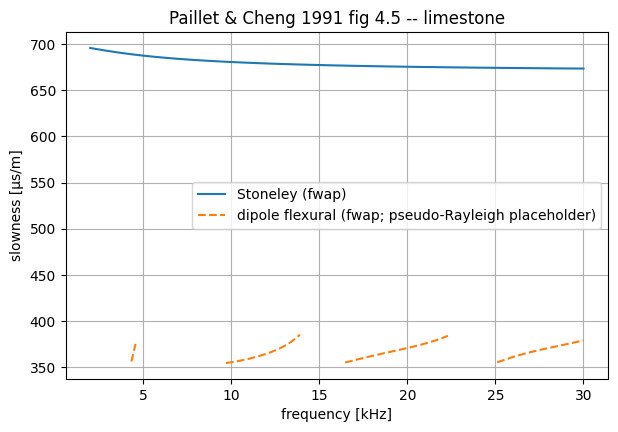

In [2]:
vp_lim, vs_lim, rho_lim = 4880.0, 2820.0, 2700.0
vf, rho_f, a = 1500.0, 1000.0, 0.10

freq_hz = np.linspace(2000.0, 30000.0, 121)
res_st = stoneley_dispersion(freq_hz, vp=vp_lim, vs=vs_lim, rho=rho_lim,
                              vf=vf, rho_f=rho_f, a=a)
# Pseudo-Rayleigh is a future extension; we plot the dipole flexural
# in the meantime as a fast-formation guided-mode reference, with a
# clearly-marked label so the reader knows it is a placeholder.
res_fl = flexural_dispersion(freq_hz, vp=vp_lim, vs=vs_lim, rho=rho_lim,
                              vf=vf, rho_f=rho_f, a=a)

fig, ax = plt.subplots()
ax.plot(freq_hz / 1e3, res_st.slowness * 1e6, label="Stoneley (fwap)")
ax.plot(freq_hz / 1e3, res_fl.slowness * 1e6,
        label="dipole flexural (fwap; pseudo-Rayleigh placeholder)",
        linestyle="--")
ax.set_xlabel("frequency [kHz]")
ax.set_ylabel("slowness [µs/m]")
ax.set_title("Paillet & Cheng 1991 fig 4.5 -- limestone")
ax.legend()
plt.show()


In [3]:
# Overlay against the digitised reference (TODO).
ref_st = overlay_csv("paillet_cheng_1991_fig4_5_stoneley.csv")
if ref_st is None:
    print("TODO: digitise Paillet & Cheng 1991 fig 4.5 (Stoneley)\n"
          "      and drop it at docs/notebooks/_data/\n"
          "      paillet_cheng_1991_fig4_5_stoneley.csv\n"
          "      The fwap Stoneley curve above is shipped with the\n"
          "      validation scaffolding (Plan I option B).")
else:
    fig, ax = plt.subplots()
    ax.plot(freq_hz / 1e3, res_st.slowness * 1e6, label="Stoneley (fwap)")
    ax.plot(ref_st[0] / 1e3, ref_st[1] * 1e6, "k:",
            label="Stoneley (digitised reference)")
    ax.set_xlabel("frequency [kHz]")
    ax.set_ylabel("slowness [µs/m]")
    ax.set_title("Paillet & Cheng 1991 fig 4.5 -- overlay")
    ax.legend()
    plt.show()


TODO: digitise Paillet & Cheng 1991 fig 4.5 (Stoneley)
      and drop it at docs/notebooks/_data/
      paillet_cheng_1991_fig4_5_stoneley.csv
      The fwap Stoneley curve above is shipped with the
      validation scaffolding (Plan I option B).


## 2. Schmitt 1988 fig 4 -- flexural slow + fast

Dipole flexural dispersion in two formations: a slow shale and a
fast limestone. Tests `flexural_dispersion`.

**Slow-formation geometry** (Schmitt 1988, table 1, "shale"):
- V_P = 2740 m/s, V_S = 1280 m/s, rho = 2400 kg/m^3
- borehole fluid: V_f = 1500 m/s, rho_f = 1000 kg/m^3
- borehole radius a = 0.10 m

**Fast-formation geometry** (Schmitt 1988, table 1, "limestone"):
- V_P = 4900 m/s, V_S = 2840 m/s, rho = 2700 kg/m^3
- same fluid and radius


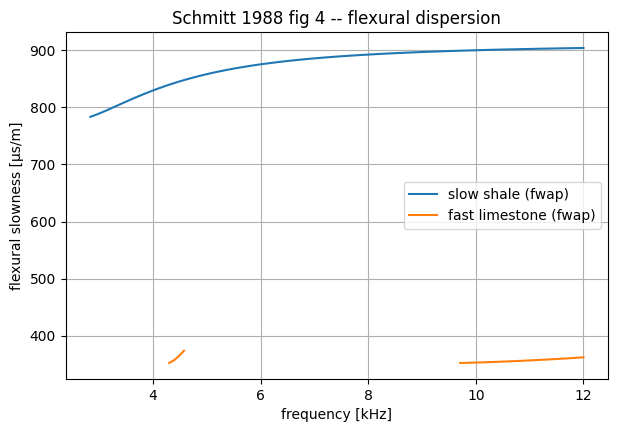

In [4]:
slow = dict(vp=2740.0, vs=1280.0, rho=2400.0,
            vf=1500.0, rho_f=1000.0, a=0.10)
fast = dict(vp=4900.0, vs=2840.0, rho=2700.0,
            vf=1500.0, rho_f=1000.0, a=0.10)
freq_hz = np.linspace(1000.0, 12000.0, 121)
res_slow = flexural_dispersion(freq_hz, **slow)
res_fast = flexural_dispersion(freq_hz, **fast)

fig, ax = plt.subplots()
ax.plot(freq_hz / 1e3, res_slow.slowness * 1e6,
        label="slow shale (fwap)")
ax.plot(freq_hz / 1e3, res_fast.slowness * 1e6,
        label="fast limestone (fwap)")
ax.set_xlabel("frequency [kHz]")
ax.set_ylabel("flexural slowness [µs/m]")
ax.set_title("Schmitt 1988 fig 4 -- flexural dispersion")
ax.legend()
plt.show()


In [5]:
ref_slow = overlay_csv("schmitt_1988_fig4_flexural_slow.csv")
ref_fast = overlay_csv("schmitt_1988_fig4_flexural_fast.csv")
if ref_slow is None and ref_fast is None:
    print("TODO: digitise Schmitt 1988 fig 4 (slow and fast)\n"
          "      and drop the CSVs at docs/notebooks/_data/.\n"
          "      Schema documented in _data/README.md.")
else:
    fig, ax = plt.subplots()
    ax.plot(freq_hz / 1e3, res_slow.slowness * 1e6,
            label="slow (fwap)")
    ax.plot(freq_hz / 1e3, res_fast.slowness * 1e6,
            label="fast (fwap)")
    if ref_slow is not None:
        ax.plot(ref_slow[0] / 1e3, ref_slow[1] * 1e6, "k:",
                label="slow (reference)")
    if ref_fast is not None:
        ax.plot(ref_fast[0] / 1e3, ref_fast[1] * 1e6, "k--",
                label="fast (reference)")
    ax.set_xlabel("frequency [kHz]")
    ax.set_ylabel("flexural slowness [µs/m]")
    ax.set_title("Schmitt 1988 fig 4 -- overlay")
    ax.legend()
    plt.show()


TODO: digitise Schmitt 1988 fig 4 (slow and fast)
      and drop the CSVs at docs/notebooks/_data/.
      Schema documented in _data/README.md.


## 3. Tang & Cheng 2004 figs 3.7 + 3.10 -- quadrupole slow + fast

n=2 quadrupole dispersion, again in slow and fast formations.
Tests `quadrupole_dispersion`. The plan-G''.e cement-bond test
already pins the cased-hole quadrupole physics direction; this
notebook section validates the unlayered baseline against the
textbook figure.

**Slow-formation geometry** (Tang & Cheng 2004, sect. 2.5):
- V_P = 2200 m/s, V_S = 800 m/s, rho = 2200 kg/m^3
- V_f = 1500 m/s, rho_f = 1000 kg/m^3, a = 0.10 m

**Fast-formation geometry** (Tang & Cheng 2004, sect. 2.5):
- V_P = 4500 m/s, V_S = 2600 m/s, rho = 2400 kg/m^3
- same fluid and radius


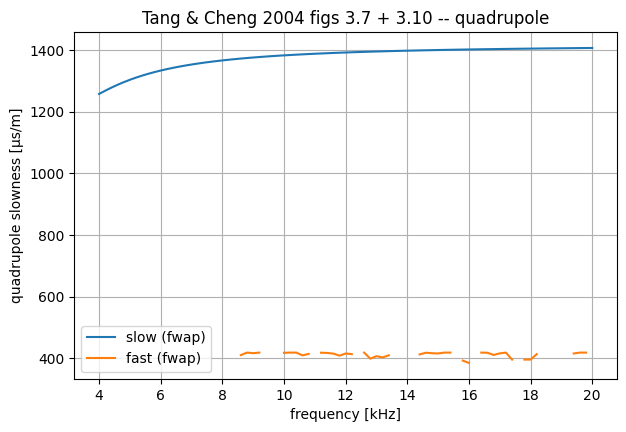

In [6]:
slow = dict(vp=2200.0, vs=800.0, rho=2200.0,
            vf=1500.0, rho_f=1000.0, a=0.10)
fast = dict(vp=4500.0, vs=2600.0, rho=2400.0,
            vf=1500.0, rho_f=1000.0, a=0.10)
freq_hz = np.linspace(2000.0, 20000.0, 91)
res_slow = quadrupole_dispersion(freq_hz, **slow)
res_fast = quadrupole_dispersion(freq_hz, **fast)

fig, ax = plt.subplots()
ax.plot(freq_hz / 1e3, res_slow.slowness * 1e6,
        label="slow (fwap)")
ax.plot(freq_hz / 1e3, res_fast.slowness * 1e6,
        label="fast (fwap)")
ax.set_xlabel("frequency [kHz]")
ax.set_ylabel("quadrupole slowness [µs/m]")
ax.set_title("Tang & Cheng 2004 figs 3.7 + 3.10 -- quadrupole")
ax.legend()
plt.show()


In [7]:
ref_slow = overlay_csv("tang_cheng_2004_fig3_7_quadrupole_slow.csv")
ref_fast = overlay_csv("tang_cheng_2004_fig3_10_quadrupole_fast.csv")
if ref_slow is None and ref_fast is None:
    print("TODO: digitise Tang & Cheng 2004 figs 3.7 + 3.10 and drop\n"
          "      CSVs at docs/notebooks/_data/.\n"
          "      Schema documented in _data/README.md.")
else:
    fig, ax = plt.subplots()
    ax.plot(freq_hz / 1e3, res_slow.slowness * 1e6, label="slow (fwap)")
    ax.plot(freq_hz / 1e3, res_fast.slowness * 1e6, label="fast (fwap)")
    if ref_slow is not None:
        ax.plot(ref_slow[0] / 1e3, ref_slow[1] * 1e6, "k:",
                label="slow (reference)")
    if ref_fast is not None:
        ax.plot(ref_fast[0] / 1e3, ref_fast[1] * 1e6, "k--",
                label="fast (reference)")
    ax.set_xlabel("frequency [kHz]")
    ax.set_ylabel("quadrupole slowness [µs/m]")
    ax.set_title("Tang & Cheng 2004 figs 3.7 + 3.10 -- overlay")
    ax.legend()
    plt.show()


TODO: digitise Tang & Cheng 2004 figs 3.7 + 3.10 and drop
      CSVs at docs/notebooks/_data/.
      Schema documented in _data/README.md.


## 4. Tang & Cheng 2004 fig 7.1 -- cased-hole Stoneley

Multi-layer Stoneley dispersion in a cased + cemented borehole.
Tests `stoneley_dispersion_layered` with the casing + cement
geometry that was the headline G.e validation deferral.

**Geometry** (Tang & Cheng 2004, sect. 7.2):
- formation: V_P = 2200 m/s, V_S = 800 m/s, rho = 2200 kg/m^3
- casing: V_P = 5860 m/s, V_S = 3140 m/s, rho = 7800 kg/m^3,
  thickness 0.01 m
- cement: V_P = 2300 m/s, V_S = 1300 m/s, rho = 1900 kg/m^3,
  thickness 0.05 m
- borehole fluid: V_f = 1500 m/s, rho_f = 1000 kg/m^3
- borehole radius a = 0.10 m


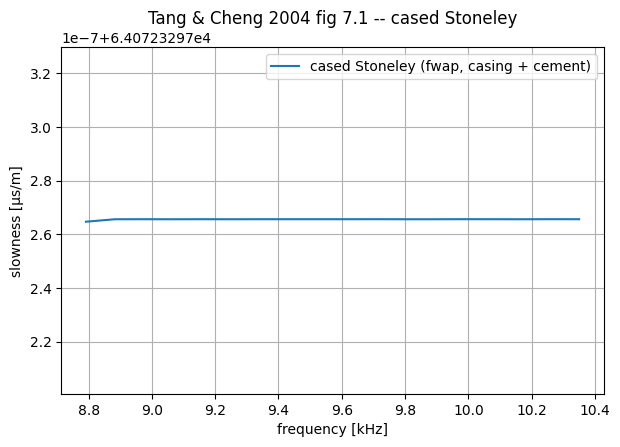

In [8]:
casing = BoreholeLayer(vp=5860.0, vs=3140.0, rho=7800.0, thickness=0.01)
cement = BoreholeLayer(vp=2300.0, vs=1300.0, rho=1900.0, thickness=0.05)
freq_hz = np.linspace(1000.0, 12000.0, 121)
res = stoneley_dispersion_layered(
    freq_hz,
    vp=2200.0, vs=800.0, rho=2200.0,
    vf=1500.0, rho_f=1000.0, a=0.10,
    layers=(casing, cement),
)

fig, ax = plt.subplots()
ax.plot(freq_hz / 1e3, res.slowness * 1e6,
        label="cased Stoneley (fwap, casing + cement)")
ax.set_xlabel("frequency [kHz]")
ax.set_ylabel("slowness [µs/m]")
ax.set_title("Tang & Cheng 2004 fig 7.1 -- cased Stoneley")
ax.legend()
plt.show()


In [9]:
ref = overlay_csv("tang_cheng_2004_fig7_1_stoneley_cased.csv")
if ref is None:
    print("TODO: digitise Tang & Cheng 2004 fig 7.1 (cased Stoneley)\n"
          "      and drop the CSV at docs/notebooks/_data/.\n"
          "      Note: this is the headline cement-bond validation\n"
          "      figure deferred from G.e.")
else:
    fig, ax = plt.subplots()
    ax.plot(freq_hz / 1e3, res.slowness * 1e6, label="fwap")
    ax.plot(ref[0] / 1e3, ref[1] * 1e6, "k:",
            label="digitised reference")
    ax.set_xlabel("frequency [kHz]")
    ax.set_ylabel("slowness [µs/m]")
    ax.set_title("Tang & Cheng 2004 fig 7.1 -- overlay")
    ax.legend()
    plt.show()


TODO: digitise Tang & Cheng 2004 fig 7.1 (cased Stoneley)
      and drop the CSV at docs/notebooks/_data/.
      Note: this is the headline cement-bond validation
      figure deferred from G.e.


## 5. Schmitt 1989 fig 5 -- VTI flexural

n=1 flexural dispersion in a VTI formation. Tests
`flexural_dispersion_vti` against the Schmitt 1989 textbook
example. The VTI tensor below is a representative shale.

**Geometry** (Schmitt 1989, sect. 4 example):
- C_11 = 23.2 GPa, C_13 =  9.0 GPa, C_33 = 18.0 GPa
- C_44 =  4.0 GPa, C_66 =  6.0 GPa
- rho = 2400 kg/m^3
- borehole fluid: V_f = 1500 m/s, rho_f = 1000 kg/m^3
- borehole radius a = 0.10 m


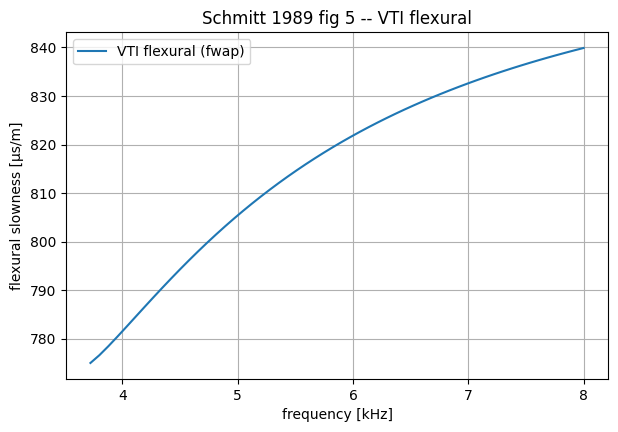

In [10]:
vti = dict(
    c11=23.2e9, c13=9.0e9, c33=18.0e9, c44=4.0e9, c66=6.0e9,
    rho=2400.0, vf=1500.0, rho_f=1000.0, a=0.10,
)
freq_hz = np.linspace(1000.0, 8000.0, 91)
res = flexural_dispersion_vti(freq_hz, **vti)

fig, ax = plt.subplots()
ax.plot(freq_hz / 1e3, res.slowness * 1e6,
        label="VTI flexural (fwap)")
ax.set_xlabel("frequency [kHz]")
ax.set_ylabel("flexural slowness [µs/m]")
ax.set_title("Schmitt 1989 fig 5 -- VTI flexural")
ax.legend()
plt.show()


In [11]:
ref = overlay_csv("schmitt_1989_fig5_flexural_vti_qP.csv")
if ref is None:
    print("TODO: digitise Schmitt 1989 fig 5 (VTI flexural) and\n"
          "      drop CSV(s) at docs/notebooks/_data/.\n"
          "      The figure has separate qP and qSV branches; both\n"
          "      filenames are documented in _data/README.md.")
else:
    fig, ax = plt.subplots()
    ax.plot(freq_hz / 1e3, res.slowness * 1e6, label="fwap")
    ax.plot(ref[0] / 1e3, ref[1] * 1e6, "k:",
            label="digitised reference")
    ax.set_xlabel("frequency [kHz]")
    ax.set_ylabel("flexural slowness [µs/m]")
    ax.set_title("Schmitt 1989 fig 5 -- overlay")
    ax.legend()
    plt.show()


TODO: digitise Schmitt 1989 fig 5 (VTI flexural) and
      drop CSV(s) at docs/notebooks/_data/.
      The figure has separate qP and qSV branches; both
      filenames are documented in _data/README.md.


## Status checklist

| Section                                | fwap curve | Digitised overlay |
|----------------------------------------|------------|-------------------|
| 1. Paillet & Cheng 1991 fig 4.5        | shipped    | TODO              |
| 2. Schmitt 1988 fig 4                  | shipped    | TODO              |
| 3. Tang & Cheng 2004 figs 3.7 / 3.10   | shipped    | TODO              |
| 4. Tang & Cheng 2004 fig 7.1           | shipped    | TODO              |
| 5. Schmitt 1989 fig 5                  | shipped    | TODO              |

## How to add a digitised overlay

1. Digitise the figure (e.g. WebPlotDigitizer) into a CSV with the
   schema described in
   [`_data/README.md`](_data/README.md): two columns,
   `freq_hz, slowness_s_per_m`, no header.
2. Name the file per the table in the README and drop it into
   `docs/notebooks/_data/`.
3. Re-execute this notebook (or just the affected section). The
   `overlay_csv` helper picks the file up automatically and the
   second cell of each section flips from the TODO branch to the
   plotted overlay.

## Validation hook

```
pytest --nbval-lax docs/notebooks/cylindrical_biot_validation.ipynb
```

`--nbval-lax` re-runs every cell and fails on any error or output
mismatch beyond floating-point noise. Once at least one CSV is
present, the per-curve RMS-deviation gate (5 % budget per Plan I)
will be added as an inline `assert` in each section's overlay
cell.
